# Baselines: DummyClassifier e Regressão Logística

Etapa 1, Passo 4: treinar modelos baseline para estabelecer referência mínima de desempenho antes da MLP.

| Modelo | Propósito |
|---|---|
| `DummyClassifier(strategy='most_frequent')` | Piso trivial: sempre prediz a classe majoritária (não churn) |
| `DummyClassifier(strategy='stratified')` | Piso probabilístico: prediz aleatoriamente respeitando a distribuição do treino |
| `LogisticRegression` | Baseline linear: referência para o ganho da MLP |

**Métricas:** AUC-ROC, PR-AUC, Recall (churn), F1 (churn), Precisão (churn)  
**Validação:** StratifiedKFold (5 folds), obrigatório com dado desbalanceado  
**Tracking:** MLflow com backend SQLite local

## 1. Setup

In [1]:
import logging
import random
import warnings

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    classification_report,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S"
)
log = logging.getLogger(__name__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_PATH = "../data/raw/telco-churn.csv"
MLFLOW_URI = "sqlite:///../mlruns.db"
EXPERIMENT_NAME = "telco-churn"
N_FOLDS = 5

plt.rcParams["figure.figsize"] = (10, 4)
sns.set_theme(style="whitegrid")

log.info("Setup concluído. SEED=%d, FOLDS=%d", SEED, N_FOLDS)

18:39:43 | INFO | Setup concluído. SEED=42, FOLDS=5


## 2. Carregamento e Pré-processamento

In [2]:
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

# Correções identificadas na EDA
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
df["Churn"] = (df["Churn"] == "Yes").astype(int)

# Remover ID: não é feature preditiva
df = df.drop(columns=["customerID"])

log.info("Dataset carregado: %s", df.shape)
log.info("Churn rate: %.1f%%", df["Churn"].mean() * 100)

print(f"Shape: {df.shape}")
print(f"Churn rate: {df['Churn'].mean():.3f} ({df['Churn'].mean()*100:.1f}%)")
df.head(3)

18:39:43 | INFO | Dataset carregado: (7043, 20)
18:39:43 | INFO | Churn rate: 26.5%


Shape: (7043, 20)
Churn rate: 0.265 (26.5%)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


## 3. Pipeline de Pré-processamento

- **Numéricas** (`MonthlyCharges`, `monthly_x_tenure`, `one_year_x_tenure`, `two_year_x_tenure`): `StandardScaler`
- **Categóricas** (demais features): `OneHotEncoder` com `drop='if_binary'`

**Features removidas:**
- `TotalCharges`: colinear com `tenure` (r=+0.83), sem sinal independente → removida
- `gender`, `PhoneService`: Cramér's V ≈ 0 com target → removidas como ruído

**Interaction terms: Contract × tenure**
`tenure` é substituído por três interaction terms contínuos, um por tipo de contrato. Isso evita multicolinearidade (`monthly + one_year + two_year = tenure`) e dá ao modelo um coeficiente separado por contrato; ele aprende que cada mês adicional reduz o risco de churn com intensidades diferentes dependendo do compromisso do cliente.

In [3]:
TARGET = "Churn"
X = df.drop(columns=[TARGET])
y = df[TARGET]

# TotalCharges removida: colinearidade com tenure (r=+0.83) sem sinal independente
# gender e PhoneService removidas: Cramér's V ≈ 0 com o target
LOW_SIGNAL = ["gender", "PhoneService", "TotalCharges"]
X = X.drop(columns=LOW_SIGNAL)

# Interaction terms: Contract × tenure para cada tipo de contrato
# Tenure captura lealdade; o efeito existe nos três grupos, com intensidades
# diferentes. Substituir tenure pelas três interações evita multicolinearidade
# (monthly + one_year + two_year = tenure) e dá ao modelo um coeficiente
# separado por contrato, aprendendo que cada mês adicional "vale mais" no
# mês a mês do que no bienal. LR não captura isso automaticamente.
X["monthly_x_tenure"]  = (X["Contract"] == "Month-to-month").astype(int) * X["tenure"]
X["one_year_x_tenure"] = (X["Contract"] == "One year").astype(int)       * X["tenure"]
X["two_year_x_tenure"] = (X["Contract"] == "Two year").astype(int)       * X["tenure"]

# tenure removido: está completamente codificado nas três interações acima
X = X.drop(columns=["tenure"])

num_features = ["MonthlyCharges", "monthly_x_tenure", "one_year_x_tenure", "two_year_x_tenure"]
cat_features = [c for c in X.columns if c not in num_features]

print(f"Features numéricas ({len(num_features)}): {num_features}")
print(f"Features removidas (baixo sinal/colinearidade): {LOW_SIGNAL + ['tenure']}")
print(f"Features categóricas ({len(cat_features)}): {cat_features}")
print(f"Total de features: {X.shape[1]}")
print(f"\nEstatísticas dos interaction terms:")
print(X[["monthly_x_tenure", "one_year_x_tenure", "two_year_x_tenure"]].describe().round(2))

Features numéricas (4): ['MonthlyCharges', 'monthly_x_tenure', 'one_year_x_tenure', 'two_year_x_tenure']
Features removidas (baixo sinal/colinearidade): ['gender', 'PhoneService', 'TotalCharges', 'tenure']
Features categóricas (14): ['SeniorCitizen', 'Partner', 'Dependents', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Total de features: 18

Estatísticas dos interaction terms:
       monthly_x_tenure  one_year_x_tenure  two_year_x_tenure
count           7043.00            7043.00            7043.00
mean               9.92               8.79              13.65
std               15.90              19.19              25.85
min                0.00               0.00               0.00
25%                0.00               0.00               0.00
50%                1.00               0.00               0.00
75%               14.00               0.00 

In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            num_features,
        ),
        (
            "cat",
            OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False),
            cat_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

log.info("Preprocessor definido: %d features numéricas, %d categóricas", len(num_features), len(cat_features))

18:39:43 | INFO | Preprocessor definido: 4 features numéricas, 14 categóricas


## 4. Função de Avaliação com Validação Cruzada

`StratifiedKFold` garante que cada fold mantenha a proporção de 26.5% de churners.

**Métricas rastreadas:**

| Métrica | Meta mínima |
|---|---|
| AUC-ROC | ≥ 0.80 |
| PR-AUC | ≥ 0.60 |
| Recall (churn) | ≥ 0.70 |
| F1 (churn) | ≥ 0.60 |
| Precisão (churn) | ≥ 0.55 |

**Por que accuracy não aparece?** Com 73.5% de classe majoritária, um classificador que sempre prediz "não churn" acerta ~73% sem detectar nenhum cancelamento. Accuracy é enganosa em problemas desbalanceados e foi conscientemente descartada.

In [5]:
from sklearn.metrics import recall_score, f1_score, precision_score

CV = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Threshold 0.4: prioriza recall, pois falso negativo tem custo maior que falso positivo
THRESHOLD = 0.4


def _make_threshold_scorer(metric_fn):
    """Retorna scorer com assinatura (estimator, X, y) usando threshold customizado."""
    def scorer(estimator, X, y):
        proba = estimator.predict_proba(X)[:, 1]
        y_pred = (proba >= THRESHOLD).astype(int)
        return metric_fn(y, y_pred, zero_division=0)
    return scorer


# Scorers prontos para uso direto em cross_validate
recall_t04 = _make_threshold_scorer(recall_score)
f1_t04 = _make_threshold_scorer(f1_score)
precision_t04 = _make_threshold_scorer(precision_score)


def evaluate_cv(pipeline: Pipeline, X: pd.DataFrame, y: pd.Series, model_name: str) -> tuple[dict, dict]:
    """Avalia pipeline com cross-validation estratificado. Retorna (métricas_resumo, cv_results_brutos)."""
    log.info("Avaliando '%s' com %d folds (threshold=%.1f)...", model_name, N_FOLDS, THRESHOLD)

    scoring = {
        "roc_auc": "roc_auc",
        "average_precision": "average_precision",   # PR-AUC
        "recall": recall_t04,
        "f1": f1_t04,
        "precision": precision_t04,
    }

    cv_results = cross_validate(
        pipeline,
        X,
        y,
        cv=CV,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1,
    )

    metrics = {
        "roc_auc_mean": float(cv_results["test_roc_auc"].mean()),
        "roc_auc_std": float(cv_results["test_roc_auc"].std()),
        "pr_auc_mean": float(cv_results["test_average_precision"].mean()),
        "pr_auc_std": float(cv_results["test_average_precision"].std()),
        "recall_mean": float(np.nan_to_num(cv_results["test_recall"].mean())),
        "recall_std": float(np.nan_to_num(cv_results["test_recall"].std())),
        "f1_mean": float(np.nan_to_num(cv_results["test_f1"].mean())),
        "f1_std": float(np.nan_to_num(cv_results["test_f1"].std())),
        "precision_mean": float(np.nan_to_num(cv_results["test_precision"].mean())),
        "precision_std": float(np.nan_to_num(cv_results["test_precision"].std())),
    }

    log.info(
        "%s → AUC-ROC=%.3f | PR-AUC=%.3f | Recall=%.3f | F1=%.3f | Precision=%.3f",
        model_name,
        metrics["roc_auc_mean"],
        metrics["pr_auc_mean"],
        metrics["recall_mean"],
        metrics["f1_mean"],
        metrics["precision_mean"],
    )
    return metrics, cv_results

## 5. Configuração do MLflow

In [6]:
import subprocess

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(EXPERIMENT_NAME)
# Desabilita auto-log para evitar métricas duplicadas ao chamar log_model
mlflow.sklearn.autolog(disable=True)

# Dataset registrado uma vez; hash calculado automaticamente pelo MLflow
mlflow_dataset = mlflow.data.from_pandas(
    df,
    source=DATA_PATH,
    name="telco-churn",
    targets="Churn",
)

# Git commit para rastreabilidade completa
try:
    GIT_COMMIT = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"], stderr=subprocess.DEVNULL
    ).decode().strip()
except Exception:
    GIT_COMMIT = "unknown"

log.info("MLflow tracking URI: %s", MLFLOW_URI)
log.info("Experimento: %s", EXPERIMENT_NAME)
log.info("Dataset hash: %s", mlflow_dataset.digest)
log.info("Git commit: %s", GIT_COMMIT)
print(f"MLflow UI: mlflow ui --backend-store-uri {MLFLOW_URI}")

18:39:44 | INFO | MLflow tracking URI: sqlite:///../mlruns.db
18:39:44 | INFO | Experimento: telco-churn
18:39:44 | INFO | Dataset hash: e136d433
18:39:44 | INFO | Git commit: 79fa4ad


MLflow UI: mlflow ui --backend-store-uri sqlite:///../mlruns.db


## 6. Baseline 1: DummyClassifier

Estabelece o **piso mínimo de desempenho**. Qualquer modelo real deve superar esses valores consistentemente para ter valor preditivo.

In [7]:
dummy_majority_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent", random_state=SEED)),
])

dummy_majority_metrics, dummy_majority_cv = evaluate_cv(dummy_majority_pipe, X, y, "Dummy (most_frequent)")

params_majority = {
    "model": "DummyClassifier",
    "strategy": "most_frequent",
    "threshold": THRESHOLD,
    "n_folds": N_FOLDS,
    "seed": SEED,
    "scaler": "StandardScaler",
    "encoder": "OneHotEncoder(drop=if_binary)",
}

# Treina no dataset completo para salvar o artefato e inferir a assinatura
dummy_majority_pipe.fit(X, y)
signature_majority = mlflow.models.infer_signature(X, dummy_majority_pipe.predict_proba(X)[:, 1])

with mlflow.start_run(run_name="dummy-most_frequent"):
    mlflow.set_tags({"stage": "baseline", "model_type": "dummy", "git_commit": GIT_COMMIT})
    mlflow.log_input(mlflow_dataset, context="training")
    mlflow.log_params(params_majority)
    mlflow.log_metrics(dummy_majority_metrics)
    for fold_idx, val in enumerate(dummy_majority_cv["test_roc_auc"]):
        mlflow.log_metric("roc_auc_fold", val, step=fold_idx)
    for fold_idx, val in enumerate(dummy_majority_cv["test_average_precision"]):
        mlflow.log_metric("pr_auc_fold", val, step=fold_idx)
    mlflow.sklearn.log_model(
        dummy_majority_pipe,
        name="model",
        input_example=X.head(3),
        signature=signature_majority,
    )
    run_id_dummy_majority = mlflow.active_run().info.run_id

log.info("Run registrado: %s", run_id_dummy_majority)

18:39:44 | INFO | Avaliando 'Dummy (most_frequent)' com 5 folds (threshold=0.4)...
18:39:45 | INFO | Dummy (most_frequent) → AUC-ROC=0.500 | PR-AUC=0.265 | Recall=0.000 | F1=0.000 | Precision=0.000
2026/05/03 18:39:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
18:39:49 | INFO | Run registrado: d2814ad119da488e95cc869a44232ec7


In [8]:
dummy_stratified_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="stratified", random_state=SEED)),
])

dummy_stratified_metrics, dummy_stratified_cv = evaluate_cv(dummy_stratified_pipe, X, y, "Dummy (stratified)")

params_stratified = {
    "model": "DummyClassifier",
    "strategy": "stratified",
    "threshold": THRESHOLD,
    "n_folds": N_FOLDS,
    "seed": SEED,
    "scaler": "StandardScaler",
    "encoder": "OneHotEncoder(drop=if_binary)",
}

# Treina no dataset completo para salvar o artefato e inferir a assinatura
dummy_stratified_pipe.fit(X, y)
signature_stratified = mlflow.models.infer_signature(X, dummy_stratified_pipe.predict_proba(X)[:, 1])

with mlflow.start_run(run_name="dummy-stratified"):
    mlflow.set_tags({"stage": "baseline", "model_type": "dummy", "git_commit": GIT_COMMIT})
    mlflow.log_input(mlflow_dataset, context="training")
    mlflow.log_params(params_stratified)
    mlflow.log_metrics(dummy_stratified_metrics)
    for fold_idx, val in enumerate(dummy_stratified_cv["test_roc_auc"]):
        mlflow.log_metric("roc_auc_fold", val, step=fold_idx)
    for fold_idx, val in enumerate(dummy_stratified_cv["test_average_precision"]):
        mlflow.log_metric("pr_auc_fold", val, step=fold_idx)
    mlflow.sklearn.log_model(
        dummy_stratified_pipe,
        name="model",
        input_example=X.head(3),
        signature=signature_stratified,
    )
    run_id_dummy_stratified = mlflow.active_run().info.run_id

log.info("Run registrado: %s", run_id_dummy_stratified)

18:39:49 | INFO | Avaliando 'Dummy (stratified)' com 5 folds (threshold=0.4)...
18:39:50 | INFO | Dummy (stratified) → AUC-ROC=0.505 | PR-AUC=0.267 | Recall=0.275 | F1=0.274 | Precision=0.273
2026/05/03 18:39:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
18:39:52 | INFO | Run registrado: e1cee03dfb864ebdae942ddec6949064


## 7. Baseline 2: Regressão Logística

Modelo linear interpretável que estabelece o **teto do linear**; o ganho da MLP deve ser medido contra esse valor.  
`class_weight='balanced'` compensa o desbalanceamento de classes sem precisar de reamostragam.

In [9]:
lr_pipe = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=SEED,
            solver="lbfgs",
            C=1.0,
        ),
    ),
])

lr_metrics, lr_cv = evaluate_cv(lr_pipe, X, y, "Logistic Regression")

params_lr = {
    "model": "LogisticRegression",
    "C": 1.0,
    "solver": "lbfgs",
    "max_iter": 1000,
    "class_weight": "balanced",
    "threshold": THRESHOLD,
    "n_folds": N_FOLDS,
    "seed": SEED,
    "scaler": "StandardScaler",
    "encoder": "OneHotEncoder(drop=if_binary)",
}

# Treina no dataset completo para salvar o artefato e inferir a assinatura
lr_pipe.fit(X, y)
signature_lr = mlflow.models.infer_signature(X, lr_pipe.predict_proba(X)[:, 1])

with mlflow.start_run(run_name="logistic-regression-balanced"):
    mlflow.set_tags({"stage": "baseline", "model_type": "linear", "git_commit": GIT_COMMIT})
    mlflow.log_input(mlflow_dataset, context="training")
    mlflow.log_params(params_lr)
    mlflow.log_metrics(lr_metrics)
    for fold_idx, val in enumerate(lr_cv["test_roc_auc"]):
        mlflow.log_metric("roc_auc_fold", val, step=fold_idx)
    for fold_idx, val in enumerate(lr_cv["test_average_precision"]):
        mlflow.log_metric("pr_auc_fold", val, step=fold_idx)
    mlflow.sklearn.log_model(
        lr_pipe,
        name="model",
        input_example=X.head(3),
        signature=signature_lr,
    )
    run_id_lr = mlflow.active_run().info.run_id

log.info("Run registrado: %s", run_id_lr)

18:39:52 | INFO | Avaliando 'Logistic Regression' com 5 folds (threshold=0.4)...
18:39:54 | INFO | Logistic Regression → AUC-ROC=0.845 | PR-AUC=0.657 | Recall=0.866 | F1=0.609 | Precision=0.470
2026/05/03 18:39:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
18:39:56 | INFO | Run registrado: b7a8ecbf1b2e46ba8eaa9dab10803ad4


## 8. Tabela Comparativa de Resultados

In [10]:
results = {
    "Dummy (most_frequent)": dummy_majority_metrics,
    "Dummy (stratified)": dummy_stratified_metrics,
    "Logistic Regression": lr_metrics,
}

TARGETS = {
    "AUC-ROC": 0.80,
    "PR-AUC":  0.60,
    "Recall":  0.70,
    "F1":      0.60,
    "Precisão": 0.55,
}

metric_map = [
    ("roc_auc_mean", "AUC-ROC"),
    ("pr_auc_mean", "PR-AUC"),
    ("recall_mean", "Recall"),
    ("f1_mean", "F1"),
    ("precision_mean", "Precisão"),
]

rows = []
for model_name, metrics in results.items():
    row = {"Modelo": model_name}
    for metric_key, label in metric_map:
        mean = metrics[metric_key]
        std = metrics[metric_key.replace("_mean", "_std")]
        row[label] = f"{mean:.3f} ± {std:.3f}"
    rows.append(row)

comparison_df = pd.DataFrame(rows).set_index("Modelo")

print(f"{'='*68}")
print(f"TABELA COMPARATIVA: BASELINES (threshold={THRESHOLD})")
print(f"{'='*68}")
display(comparison_df)

print("\nMetas mínimas:")
for label, target in TARGETS.items():
    print(f"  {label:<10}: >= {target:.2f}")

TABELA COMPARATIVA: BASELINES (threshold=0.4)


,AUC-ROC,PR-AUC,Recall,F1,Precisão
Modelo,,,,,
Dummy (most_frequent),0.500 ± 0.000,0.265 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000
Dummy (stratified),0.505 ± 0.007,0.267 ± 0.003,0.275 ± 0.011,0.274 ± 0.011,0.273 ± 0.011
Logistic Regression,0.845 ± 0.014,0.657 ± 0.026,0.866 ± 0.019,0.609 ± 0.015,0.470 ± 0.014



Metas mínimas:
  AUC-ROC   : >= 0.80
  PR-AUC    : >= 0.60
  Recall    : >= 0.70
  F1        : >= 0.60
  Precisão  : >= 0.55


## 9. Visualizações: ROC e PR Curves

Os modelos foram treinados no dataset completo nas células anteriores para gerar as curvas abaixo. Isso não é data leakage: as métricas oficiais vêm do `cross_validate` (5 folds), onde o modelo nunca vê os dados de teste durante o treino. O fit completo existe apenas para visualização, seguindo a prática padrão: avalia com CV, entrega modelo treinado em todos os dados disponíveis.

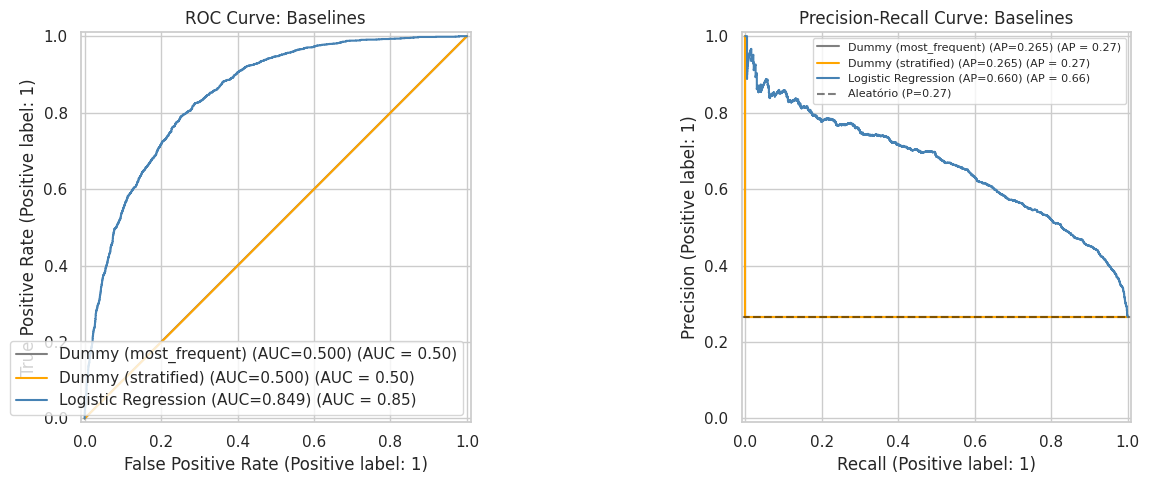

18:39:57 | INFO | Curvas logadas no MLflow (run b7a8ecbf1b2e46ba8eaa9dab10803ad4)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_for_viz = [
    ("Dummy (most_frequent)", dummy_majority_pipe, "gray"),
    ("Dummy (stratified)", dummy_stratified_pipe, "orange"),
    ("Logistic Regression", lr_pipe, "steelblue"),
]

for name, pipe, color in models_for_viz:
    try:
        y_score = pipe.predict_proba(X)[:, 1]
    except AttributeError:
        # DummyClassifier com most_frequent pode não ter predict_proba útil
        y_score = pipe.predict(X).astype(float)

    roc_auc = roc_auc_score(y, y_score)
    pr_auc = average_precision_score(y, y_score)

    RocCurveDisplay.from_predictions(
        y, y_score,
        name=f"{name} (AUC={roc_auc:.3f})",
        ax=axes[0],
        color=color,
    )
    PrecisionRecallDisplay.from_predictions(
        y, y_score,
        name=f"{name} (AP={pr_auc:.3f})",
        ax=axes[1],
        color=color,
    )

axes[0].set_title("ROC Curve: Baselines")
axes[1].set_title("Precision-Recall Curve: Baselines")

# Linha de referência aleatória no PR curve
churn_rate = y.mean()
axes[1].axhline(y=churn_rate, color="black", linestyle="--", alpha=0.5,
                label=f"Aleatório (P={churn_rate:.2f})")
axes[1].legend(fontsize=8)

plt.tight_layout()
with mlflow.start_run(run_id=run_id_lr):
    mlflow.log_figure(fig, "baselines_curves.png")
plt.show()
log.info("Curvas logadas no MLflow (run %s)", run_id_lr)

## 10. Análise de Coeficientes da Regressão Logística

Os coeficientes da Regressão Logística validam se o modelo aprendeu os padrões identificados na EDA.

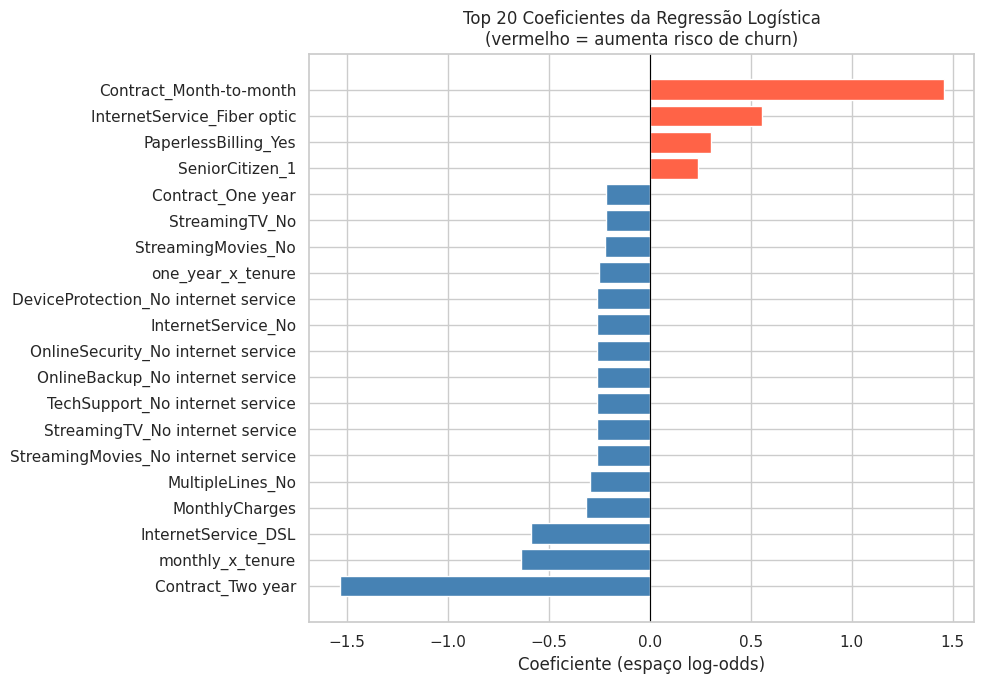

18:39:57 | INFO | Coeficientes logados no MLflow (run b7a8ecbf1b2e46ba8eaa9dab10803ad4)


In [12]:
feature_names = lr_pipe.named_steps["preprocessor"].get_feature_names_out()
coefs = lr_pipe.named_steps["classifier"].coef_[0]

coef_df = (
    pd.DataFrame({"feature": feature_names, "coef": coefs})
    .assign(abs_coef=lambda d: d["coef"].abs())
    .sort_values("abs_coef", ascending=False)
    .head(20)
    .sort_values("coef")
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["tomato" if c > 0 else "steelblue" for c in coef_df["coef"]]
ax.barh(coef_df["feature"], coef_df["coef"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 20 Coeficientes da Regressão Logística\n(vermelho = aumenta risco de churn)", fontsize=12)
ax.set_xlabel("Coeficiente (espaço log-odds)")
plt.tight_layout()
with mlflow.start_run(run_id=run_id_lr):
    mlflow.log_figure(fig, "lr_coefficients.png")
plt.show()
log.info("Coeficientes logados no MLflow (run %s)", run_id_lr)

## 11. Matriz de Confusão da Regressão Logística

Análise do trade-off entre falso positivo (cliente retido desnecessariamente) e falso negativo (churn não detectado).

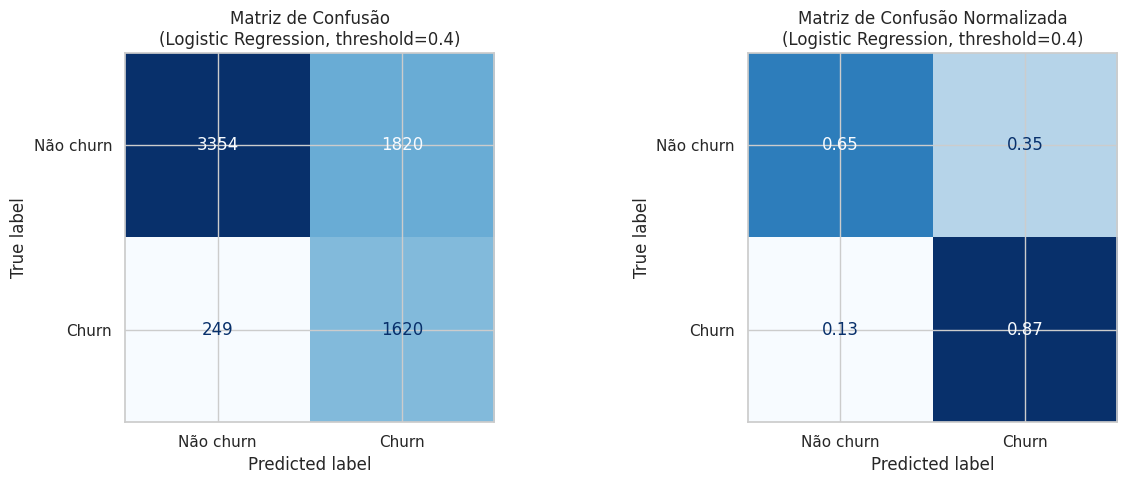


Classification Report: Logistic Regression (threshold=0.4):
           precision  recall  f1-score  support
Não churn      0.931   0.648     0.764     5174
Churn          0.471   0.867     0.610     1869


In [13]:
y_proba_lr = lr_pipe.predict_proba(X)[:, 1]
# Threshold 0.4: prioriza recall, pois falso negativo tem custo maior que falso positivo
y_pred_lr_t04 = (y_proba_lr >= THRESHOLD).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y, y_pred_lr_t04,
    display_labels=["Não churn", "Churn"],
    ax=axes[0],
    colorbar=False,
    cmap="Blues",
)
axes[0].set_title(f"Matriz de Confusão\n(Logistic Regression, threshold={THRESHOLD})")

ConfusionMatrixDisplay.from_predictions(
    y, y_pred_lr_t04,
    display_labels=["Não churn", "Churn"],
    ax=axes[1],
    colorbar=False,
    cmap="Blues",
    normalize="true",
)
axes[1].set_title(f"Matriz de Confusão Normalizada\n(Logistic Regression, threshold={THRESHOLD})")

plt.tight_layout()
plt.show()

report = classification_report(
    y, y_pred_lr_t04,
    target_names=["Não churn", "Churn"],
    output_dict=True,
)
report_df = pd.DataFrame(report).T.loc[["Não churn", "Churn"], ["precision", "recall", "f1-score", "support"]]
report_df["support"] = report_df["support"].astype(int)

print(f"\nClassification Report: Logistic Regression (threshold={THRESHOLD}):")
print(report_df.to_string(float_format="{:.3f}".format))

## 12. Resumo e Referência para a MLP

Os valores abaixo são os **targets mínimos** que a MLP deve superar para justificar sua complexidade adicional.

In [14]:
import pathlib

print("=" * 62)
print(f"REFERÊNCIA PARA A MLP (threshold={THRESHOLD})")
print("=" * 62)

lr_m = lr_metrics
performance_targets = [
    ("AUC-ROC",  "roc_auc_mean",   "roc_auc_std",   0.80),
    ("PR-AUC",   "pr_auc_mean",    "pr_auc_std",    0.60),
    ("Recall",   "recall_mean",    "recall_std",    0.70),
    ("F1",       "f1_mean",        "f1_std",        0.60),
    ("Precisão", "precision_mean", "precision_std", 0.55),
]

print(f"\n{'Métrica':<12} {'LR Baseline':>16} {'Meta':>12} {'Status':>8}")
print("-" * 52)
for label, mean_k, std_k, target in performance_targets:
    val = lr_m[mean_k]
    std = lr_m[std_k]
    status = "OK" if val >= target else "ABAIXO"
    print(f"{label:<12} {val:>6.3f} ± {std:.3f}  {target:>12.2f} {status:>8}")

print("\nA MLP deve superar os valores da coluna 'LR Baseline' e atingir as metas.")

print("\n" + "=" * 62)
print("CRITÉRIOS GO/NO-GO PARA PRODUÇÃO")
print("=" * 62)
go_nogo = [
    ("AUC-ROC", "roc_auc_mean", 0.80),
    ("PR-AUC",  "pr_auc_mean",  0.60),
    ("Recall",  "recall_mean",  0.70),
]
print(f"\n{'Critério':<10} {'LR Baseline':>14} {'Mínimo':>8} {'Go/No-Go':>10}")
print("-" * 46)
for label, key, target in go_nogo:
    val = lr_m[key]
    verdict = "GO" if val >= target else "NO-GO"
    print(f"{label:<10} {val:>14.3f} {target:>8.2f} {verdict:>10}")

# Loga o notebook como artefato para reprodutibilidade completa
notebook_path = pathlib.Path("02-baselines.ipynb")
if notebook_path.exists():
    with mlflow.start_run(run_id=run_id_lr):
        mlflow.log_artifact(str(notebook_path))
    log.info("Notebook logado como artefato no MLflow (run %s)", run_id_lr)

log.info("Baselines concluídos. Runs registrados no MLflow: %s", EXPERIMENT_NAME)

18:39:57 | INFO | Notebook logado como artefato no MLflow (run b7a8ecbf1b2e46ba8eaa9dab10803ad4)
18:39:57 | INFO | Baselines concluídos. Runs registrados no MLflow: telco-churn


REFERÊNCIA PARA A MLP (threshold=0.4)

Métrica           LR Baseline         Meta   Status
----------------------------------------------------
AUC-ROC       0.845 ± 0.014          0.80       OK
PR-AUC        0.657 ± 0.026          0.60       OK
Recall        0.866 ± 0.019          0.70       OK
F1            0.609 ± 0.015          0.60       OK
Precisão      0.470 ± 0.014          0.55   ABAIXO

A MLP deve superar os valores da coluna 'LR Baseline' e atingir as metas.

CRITÉRIOS GO/NO-GO PARA PRODUÇÃO

Critério      LR Baseline   Mínimo   Go/No-Go
----------------------------------------------
AUC-ROC             0.845     0.80         GO
PR-AUC              0.657     0.60         GO
Recall              0.866     0.70         GO
